In [ ]:
!pip install opencv-python mediapipe==0.10.13 tensorflow kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"oindrilapaulxii24","key":"95ed67e2d3ffef7106f85d444d20f0b3"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d oindrilapaul24/digits-read

Dataset URL: https://www.kaggle.com/datasets/oindrilapaul24/digits-read
License(s): unknown
 80% 131M/163M [00:00<00:00, 1.36GB/s]
100% 163M/163M [00:00<00:00, 1.26GB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/digits-read.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.2 MB/s eta 0:00:00


In [ ]:

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import mediapipe as mp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from hmmlearn import hmm
from scipy.stats import skew, kurtosis
from scipy.spatial.distance import euclidean
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
VIDEO_DIR = "/content/AVDigits"
SAVE_DIR = "/content/lip_landmarks"
RANDOM_STATE = 42

# Create save directory
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:

def compute_geometric_features(landmarks):
    """Extract comprehensive geometric features from lip landmarks"""
    features = []
    points = landmarks.reshape(-1, 2)

    # 1. Raw coordinates
    features.extend(landmarks.flatten())

    # 2. Centroid
    centroid = np.mean(points, axis=0)
    features.extend(centroid)

    # 3. Distances from centroid
    distances = [euclidean(p, centroid) for p in points]
    features.extend([np.mean(distances), np.std(distances),
                    np.max(distances), np.min(distances)])

    # 4. Bounding box features
    x_coords, y_coords = points[:, 0], points[:, 1]
    width = np.max(x_coords) - np.min(x_coords)
    height = np.max(y_coords) - np.min(y_coords)
    aspect_ratio = width / (height + 1e-6)
    features.extend([width, height, aspect_ratio])

    # 5. Statistical moments
    features.extend([np.mean(x_coords), np.std(x_coords), skew(x_coords), kurtosis(x_coords)])
    features.extend([np.mean(y_coords), np.std(y_coords), skew(y_coords), kurtosis(y_coords)])

    # 6. Pairwise distances (key points)
    key_indices = [0, len(points)//4, len(points)//2, 3*len(points)//4, -1]
    for i in range(len(key_indices)-1):
        dist = euclidean(points[key_indices[i]], points[key_indices[i+1]])
        features.append(dist)

    # 7. Mouth opening
    if len(points) > 10:
        mouth_opening = euclidean(points[3], points[9]) if len(points) > 9 else 0
        features.append(mouth_opening)

    return np.array(features)

def extract_temporal_features(landmark_sequence):
    """Extract temporal features from a sequence of landmarks"""
    if len(landmark_sequence) == 0:
        return None

    features = []
    seq_array = np.array(landmark_sequence)

    # Statistical features over time
    features.extend(np.mean(seq_array, axis=0))
    features.extend(np.std(seq_array, axis=0))
    features.extend(np.max(seq_array, axis=0))
    features.extend(np.min(seq_array, axis=0))

    # Velocity features
    if len(landmark_sequence) > 1:
        velocities = np.diff(seq_array, axis=0)
        features.extend(np.mean(velocities, axis=0))
        features.extend(np.std(velocities, axis=0))
    else:
        features.extend(np.zeros(seq_array.shape[1]))
        features.extend(np.zeros(seq_array.shape[1]))

    return np.array(features)


In [ ]:

# ============================================================================
# STEP 1: IMPROVED LIP LANDMARK EXTRACTION
# ============================================================================
print("=" * 80)
print("STEP 1: Processing Video Files - Enhanced Lip Landmark Extraction")
print("=" * 80)

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=False, max_num_faces=1, refine_landmarks=True)

OUTER_LIP = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 88, 95]
INNER_LIP = [78, 191, 80, 81, 82, 13, 312, 311, 310, 415, 308, 324, 318, 402, 317, 14, 87, 178, 88, 95]
lip_indices = list(set(OUTER_LIP + INNER_LIP))

video_files = [f for f in os.listdir(VIDEO_DIR) if f.endswith(".mp4")]
video_sequences = {}
all_video_features = []
all_video_labels = []

if video_files:
    for video_file in video_files:
        filepath = os.path.join(VIDEO_DIR, video_file)
        label = int(video_file.split('_')[1])

        cap = cv2.VideoCapture(filepath)
        print(f"Processing: {video_file} - Label: {label}")

        frame_landmarks = []
        frame_count = 0
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        sample_interval = max(1, total_frames // 30)

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            if frame_count % sample_interval != 0:
                frame_count += 1
                continue

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = face_mesh.process(rgb)

            if results.multi_face_landmarks:
                h, w, _ = frame.shape
                landmarks = results.multi_face_landmarks[0]

                lip_points = []
                for i in lip_indices:
                    x = landmarks.landmark[i].x * w
                    y = landmarks.landmark[i].y * h
                    lip_points.append([x, y])

                lip_points = np.array(lip_points)

                if len(lip_points) > 0:
                    x_min, y_min = np.min(lip_points, axis=0)
                    x_max, y_max = np.max(lip_points, axis=0)
                    normalized_points = (lip_points - np.array([x_min, y_min])) / (np.array([x_max - x_min, y_max - y_min]) + 1e-6)

                    frame_landmarks.append(normalized_points)

                    # Save for later use
                    base_name = f"{os.path.splitext(video_file)[0]}_frame{frame_count}"
                    npy_path = os.path.join(SAVE_DIR, base_name + ".npy")
                    np.save(npy_path, normalized_points)

            frame_count += 1

        cap.release()

        if len(frame_landmarks) >= 3:
            if label not in video_sequences:
                video_sequences[label] = []
            video_sequences[label].append(frame_landmarks)

            # Extract temporal features
            feature_seq = [compute_geometric_features(lm) for lm in frame_landmarks]
            temporal_features = extract_temporal_features(feature_seq)

            if temporal_features is not None:
                all_video_features.append(temporal_features)
                all_video_labels.append(label)

    print(f"Processed {len(video_files)} video files")
else:
    print("No .mp4 files found")


STEP 1: Processing Video Files - Enhanced Lip Landmark Extraction
Processing: S4_5_08.mp4 - Label: 5
Processing: S3_4_02.mp4 - Label: 4
Processing: S5_8_02.mp4 - Label: 8
Processing: S5_6_04.mp4 - Label: 6
Processing: S1_6_04.mp4 - Label: 6
Processing: S3_2_02.mp4 - Label: 2
Processing: S2_4_01.mp4 - Label: 4
Processing: S3_3_01.mp4 - Label: 3
Processing: S1_6_07.mp4 - Label: 6
Processing: S3_0_08.mp4 - Label: 0
Processing: S2_8_04.mp4 - Label: 8
Processing: S5_5_02.mp4 - Label: 5
Processing: S5_9_09.mp4 - Label: 9
Processing: S3_8_05.mp4 - Label: 8
Processing: S4_8_03.mp4 - Label: 8
Processing: S4_8_09.mp4 - Label: 8
Processing: S4_2_02.mp4 - Label: 2
Processing: S1_4_03.mp4 - Label: 4
Processing: S5_0_06.mp4 - Label: 0
Processing: S2_2_09.mp4 - Label: 2
Processing: S2_3_06.mp4 - Label: 3
Processing: S1_8_07.mp4 - Label: 8
Processing: S5_9_02.mp4 - Label: 9
Processing: S1_7_05.mp4 - Label: 7
Processing: S3_5_04.mp4 - Label: 5
Processing: S4_7_07.mp4 - Label: 7
Processing: S2_0_08.mp4 

In [ ]:
print("Number of videos for each digit:")
for label, sequences in video_sequences.items():
    print(f"Digit {label}: {len(sequences)} videos")

Number of videos for each digit:
Digit 5: 54 videos
Digit 4: 54 videos
Digit 8: 54 videos
Digit 6: 54 videos
Digit 2: 54 videos
Digit 3: 54 videos
Digit 0: 54 videos
Digit 9: 54 videos
Digit 7: 54 videos
Digit 1: 54 videos


In [ ]:
# STEP 2: ENHANCED DATA AUGMENTATION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 2: Enhanced Data Augmentation")
print("=" * 80)

def augment_sequence(landmark_sequence, num_augments=3):
    """Augment a sequence of landmarks"""
    augmented_sequences = []

    for _ in range(num_augments):
        aug_seq = []
        for landmarks in landmark_sequence:
            points = landmarks.copy()

            # Random rotation
            angle = random.uniform(-10, 10)
            theta = np.radians(angle)
            c, s = np.cos(theta), np.sin(theta)
            rotation_matrix = np.array([[c, -s], [s, c]])

            centroid = np.mean(points, axis=0)
            rotated = np.dot(points - centroid, rotation_matrix) + centroid

            # Random scaling
            scale = random.uniform(0.95, 1.05)
            scaled = (rotated - centroid) * scale + centroid

            # Random shift
            shift = np.random.uniform(-0.02, 0.02, size=2)
            shifted = scaled + shift
            shifted = np.clip(shifted, 0, 1)

            aug_seq.append(shifted)

        augmented_sequences.append(aug_seq)

    return augmented_sequences

# Apply augmentation
augmented_features = []
augmented_labels = []

for label, sequences in video_sequences.items():
    for seq in sequences:
        # Original
        feature_seq = [compute_geometric_features(lm) for lm in seq]
        temporal_features = extract_temporal_features(feature_seq)
        if temporal_features is not None:
            augmented_features.append(temporal_features)
            augmented_labels.append(label)

        # Augmented
        aug_sequences = augment_sequence(seq, num_augments=3)
        for aug_seq in aug_sequences:
            feature_seq = [compute_geometric_features(lm) for lm in aug_seq]
            temporal_features = extract_temporal_features(feature_seq)
            if temporal_features is not None:
                augmented_features.append(temporal_features)
                augmented_labels.append(label)

X_visual = np.array(augmented_features)
y_visual = np.array(augmented_labels)

print(f"Total samples after augmentation: {len(X_visual)}")
print(f"Feature dimensions: {X_visual.shape[1]}")



STEP 2: Enhanced Data Augmentation
Total samples after augmentation: 2160
Feature dimensions: 504


In [ ]:
# ============================================================================
# STEP 3: IMPROVED HMM TRAINING
# ============================================================================
print("\n" + "=" * 80)
print("STEP 3: Training Improved HMM Models")
print("=" * 80)

hmm_models = {}
unique_labels = np.unique(y_visual)

for label in unique_labels:
    if label in video_sequences and len(video_sequences[label]) >= 2:
        sequences = []
        for seq in video_sequences[label]:
            feature_seq = [compute_geometric_features(lm) for lm in seq]
            sequences.append(np.array(feature_seq))

        X_hmm = np.vstack(sequences)
        lengths = [len(seq) for seq in sequences]

        model = hmm.GaussianHMM(
            # n_components=5,
            # covariance_type="diag",
            # n_iter=150,
            # random_state=RANDOM_STATE
            n_components=3,
            covariance_type="diag",
            n_iter=150,
            random_state=42,
            init_params="stmc",
            params="stmc"
        )

        try:
            model.fit(X_hmm, lengths)
            hmm_models[label] = model
            print(f"Trained HMM for digit {label} with {len(sequences)} sequences")
        except Exception as e:
            print(f"Failed for digit {label}: {e}")

print(f"Successfully trained {len(hmm_models)} HMM models")



STEP 3: Training Improved HMM Models
Trained HMM for digit 0 with 54 sequences
Trained HMM for digit 1 with 54 sequences


Trained HMM for digit 2 with 54 sequences


Trained HMM for digit 3 with 54 sequences
Trained HMM for digit 4 with 54 sequences
Trained HMM for digit 5 with 54 sequences
Trained HMM for digit 6 with 54 sequences
Trained HMM for digit 7 with 54 sequences
Trained HMM for digit 8 with 54 sequences
Trained HMM for digit 9 with 54 sequences
Successfully trained 10 HMM models


In [ ]:
# ============================================================================
# STEP 4: ENHANCED FEATURE FUSION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 4: Enhanced Feature Fusion with HMM Scores")
print("=" * 80)

X_with_hmm = []

for sample in X_visual:
    hmm_scores = []
    sample_2d = sample.reshape(1, -1)

    for label in sorted(unique_labels):
        if label in hmm_models:
            try:
                score = hmm_models[label].score(sample_2d)
                hmm_scores.append(score)
            except:
                # hmm_scores.append(-1000)
                hmm_scores.append(-1e6)
        else:
            hmm_scores.append(-1000)

    hmm_scores = np.array(hmm_scores)
    if np.std(hmm_scores) > 0:
        hmm_scores = (hmm_scores - np.mean(hmm_scores)) / np.std(hmm_scores)

    combined = np.concatenate([sample, hmm_scores])
    X_with_hmm.append(combined)

X_with_hmm = np.array(X_with_hmm)
print(f"Features with HMM: {X_with_hmm.shape}")



STEP 4: Enhanced Feature Fusion with HMM Scores
Features with HMM: (2160, 514)


In [ ]:
import pickle
from google.colab import files

hmm_filename = 'hmm_digit.pkl'
with open(hmm_filename, 'wb') as file:
    pickle.dump(hmm_models, file)
print(f"HMM models saved as {hmm_filename}")
files.download(hmm_filename)

HMM models saved as hmm_digit.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================================
# STEP 5: OPTIMIZED PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("STEP 5: Optimized Preprocessing")
print("=" * 80)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_with_hmm)

pca = PCA(n_components=0.98, random_state=RANDOM_STATE)
X_reduced = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_reduced.shape[1]}")
print(f"Variance explained: {sum(pca.explained_variance_ratio_):.4f}")

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_visual, test_size=0.2, random_state=RANDOM_STATE, stratify=y_visual
)

print(f"Training: {len(X_train)}, Testing: {len(X_test)}")



STEP 5: Optimized Preprocessing
Original dimensions: 514
Reduced dimensions: 62
Variance explained: 0.9802
Training: 1728, Testing: 432


In [ ]:
import pickle
from google.colab import files

pca_filename = 'pca_digit.pkl'
with open(pca_filename, 'wb') as file:
    pickle.dump(pca, file)

print(f"PCA model saved as {pca_filename}")
files.download(pca_filename)

PCA model saved as pca_digit.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Model train

# **Random Forest**

In [ ]:

# ============================================================================
# STEP 6: OPTIMIZED RANDOM FOREST
# ============================================================================
print("\n" + "=" * 80)
print("STEP 6: Training Optimized Random Forest")
print("=" * 80)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nCV Scores: {cv_scores}")
print(f"Mean CV: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")


STEP 6: Training Optimized Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.2s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.1s 


CV Scores: [0.74566474 0.80057803 0.80346821 0.79130435 0.84347826]
Mean CV: 0.7969 (+/- 0.0312)


[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.2s finished



STEP 7: Model Evaluation


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 446 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 500 out of 500 | elapsed:    0.2s finished



🌳 Random Forest + Enhanced HMM Results:
Training Accuracy: 1.0000
Testing Accuracy: 0.7940
Precision: 0.7995
Recall: 0.7941

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85        43
           1       0.80      0.77      0.79        43
           2       0.79      0.72      0.76        43
           3       0.65      0.77      0.71        44
           4       0.88      0.84      0.86        43
           5       0.73      0.74      0.74        43
           6       0.87      0.75      0.80        44
           7       0.71      0.74      0.73        43
           8       0.95      0.91      0.93        43
           9       0.81      0.79      0.80        43

    accuracy                           0.79       432
   macro avg       0.80      0.79      0.80       432
weighted avg       0.80      0.79      0.79       432



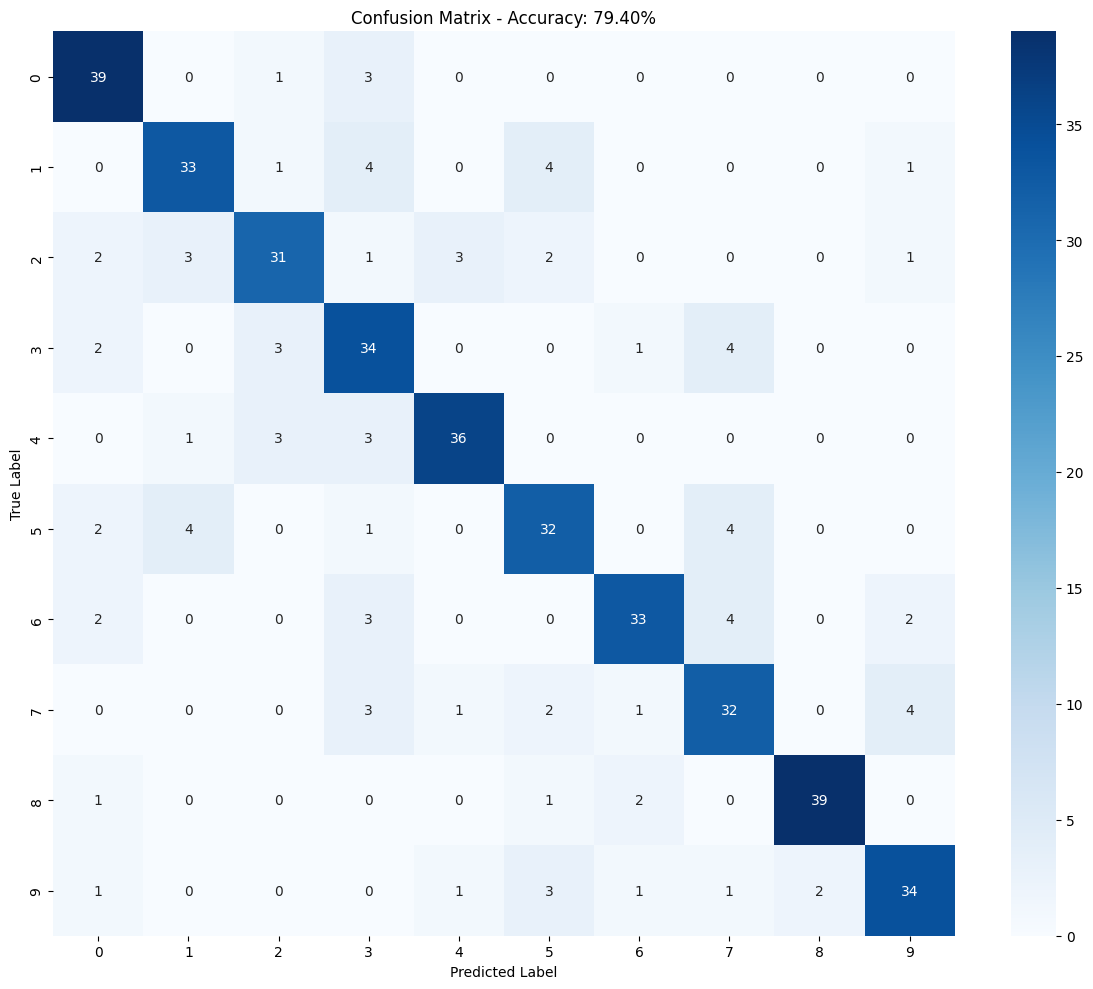

In [ ]:
# ============================================================================
# STEP 7: COMPREHENSIVE EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("STEP 7: Model Evaluation")
print("=" * 80)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n🌳 Random Forest + Enhanced HMM Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='macro'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix - Accuracy: {test_acc:.2%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_improved.png', dpi=300)
plt.show()


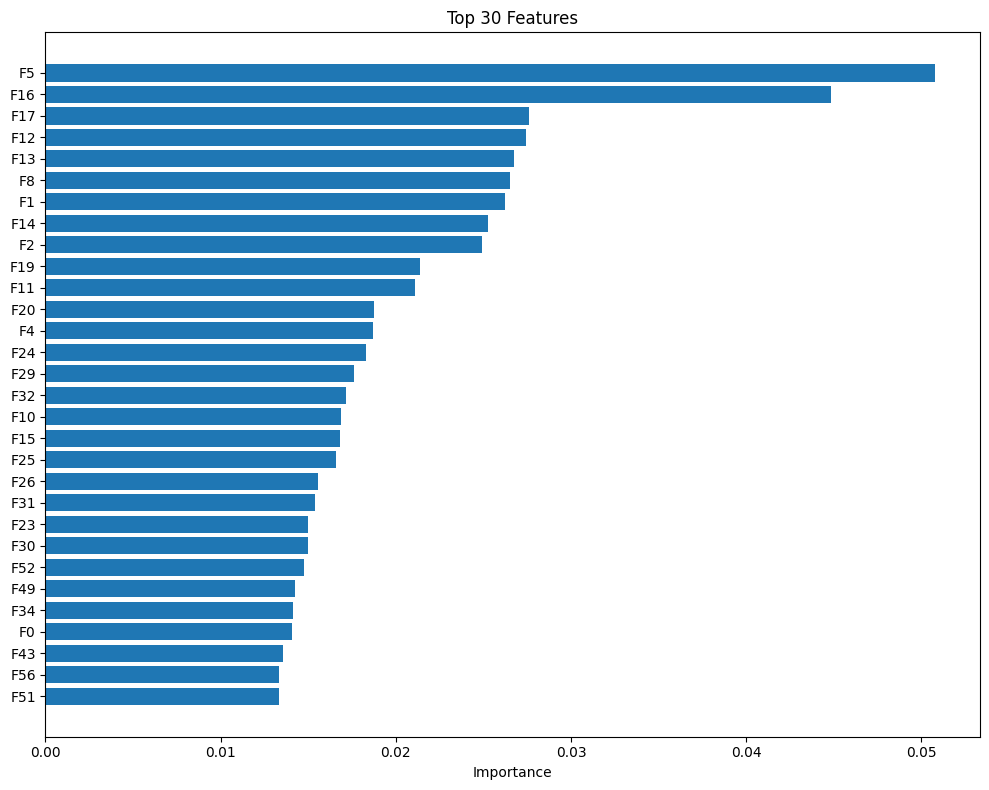


✓ Final Test Accuracy: 79.40%


In [ ]:

# Feature Importance
importance = rf_model.feature_importances_
top_n = min(30, len(importance))
top_idx = np.argsort(importance)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importance[top_idx])
plt.yticks(range(top_n), [f'F{i}' for i in top_idx])
plt.xlabel('Importance')
plt.title(f'Top {top_n} Features')
plt.tight_layout()
plt.savefig('/content/feature_importance_improved.png', dpi=600)
plt.show()

print(f"\n✓ Final Test Accuracy: {test_acc:.2%}")
print("=" * 80)


In [ ]:
rf_model.n_features_in_

62

In [ ]:
np.bincount(y_test)

array([43, 43, 43, 44, 43, 43, 44, 43, 43, 43])

In [ ]:
np.bincount(y_train)

array([173, 173, 173, 172, 173, 173, 172, 173, 173, 173])

In [ ]:
# ============================================================================
# STEP 8: Visualize Training and Testing Accuracy
# ============================================================================
print("\n" + "=" * 80)
print("STEP 8: Visualizing Training and Testing Accuracy")
print("=" * 80)

labels = ['Training Accuracy', 'Testing Accuracy']
accuracies = [train_acc, test_acc]

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.show()

print(f"\n✓ Final Test Accuracy: {test_acc:.2%}")
print("=" * 80)

In [ ]:
import pickle
from google.colab import files

# Save the trained Random Forest model
model_filename = 'random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Model saved as {model_filename}")

# Download the model file
files.download(model_filename)

Model saved as random_forest_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>